In [28]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [29]:
df = pd.read_csv("Data/prices.csv")

Data Cleaning


In [30]:
# print(df.duplicated().sum())
# print(df.isnull().sum())

df=df.dropna()
df=df.drop_duplicates()
print(df.head())

         date  item       city  price
0  2025-01-01  Rice  Kathmandu    120
1  2025-01-01  Rice  Bhaktapur    118
2  2025-01-01  Rice   Lalitpur    119
3  2025-01-01   Oil  Kathmandu    220
4  2025-01-01   Oil  Bhaktapur    215


In [31]:
df["date"] = pd.to_datetime(df["date"])
print(df.head())

        date  item       city  price
0 2025-01-01  Rice  Kathmandu    120
1 2025-01-01  Rice  Bhaktapur    118
2 2025-01-01  Rice   Lalitpur    119
3 2025-01-01   Oil  Kathmandu    220
4 2025-01-01   Oil  Bhaktapur    215


Average Price per Item


In [32]:
avg_price = df.groupby("item")["price"].mean()
print("\nAverage Price:\n", avg_price)


Average Price:
 item
Oil           232.666667
Rice          126.166667
Vegetables     85.000000
Name: price, dtype: float64


Inflation Trend (item-wise)

In [33]:
trend = df.groupby(["date", "item"])["price"].mean().reset_index()

Visualization 1: Price Trend

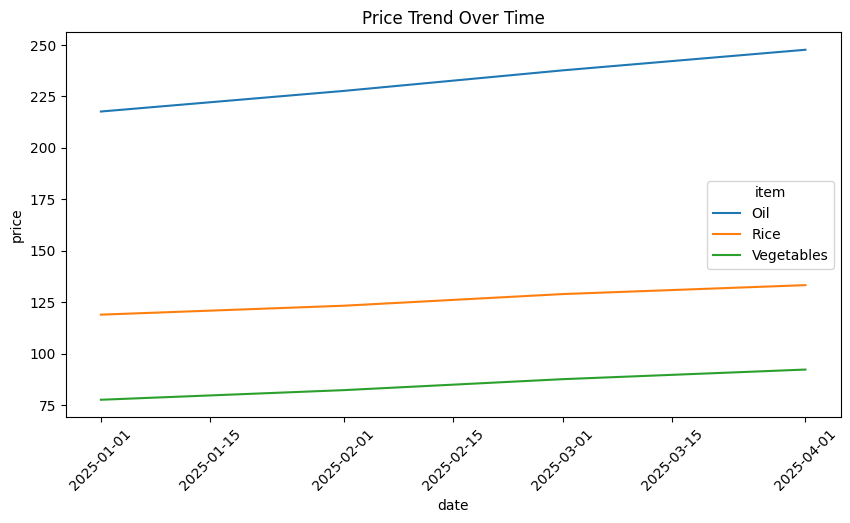

In [34]:
plt.figure(figsize=(10,5))
sns.lineplot(data=trend, x="date", y="price", hue="item")
plt.title("Price Trend Over Time")
plt.xticks(rotation=45)
plt.show()

Visualization 2: City Comparison

        city       price
0  Bhaktapur  149.111111
1  Kathmandu  153.333333
2   Lalitpur  151.222222


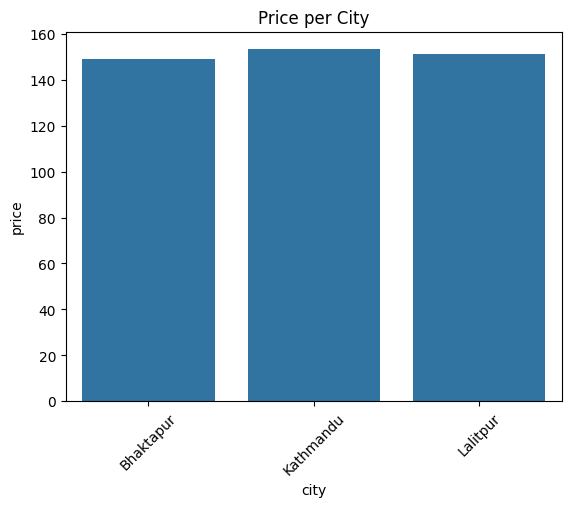

In [47]:
city_price = df.groupby("city")["price"].mean().reset_index()
print(city_price)

sns.barplot(data=city_price, x="city", y="price")
plt.title("Price per City")
plt.xticks(rotation=45)
plt.show()

Visualization 3: Heatmap

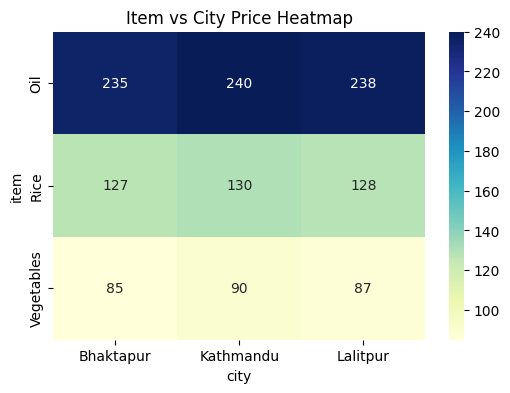

In [48]:
pivot = df.pivot_table(values="price", index="item", columns="city", aggfunc="mean")

plt.figure(figsize=(6,4))
sns.heatmap(pivot, annot=True, cmap="YlGnBu",fmt=".0f")
plt.title("Item vs City Price Heatmap")
plt.show()

Inflation Calculation

In [49]:
df = df.sort_values("date")
df["pct_change"] = df.groupby("item")["price"].pct_change()*100

print("\nInflation (% change): \n" + df.to_string())


Inflation (% change): 
         date        item       city  price  pct_change
12 2025-02-01         Oil  Kathmandu    230         NaN
9  2025-02-01        Rice  Kathmandu    125         NaN
10 2025-02-01        Rice  Bhaktapur    122   -2.400000
11 2025-02-01        Rice   Lalitpur    123    0.819672
13 2025-02-01         Oil  Bhaktapur    225   -2.173913
14 2025-02-01         Oil   Lalitpur    228    1.333333
15 2025-02-01  Vegetables  Kathmandu     85         NaN
16 2025-02-01  Vegetables  Bhaktapur     80   -5.882353
17 2025-02-01  Vegetables   Lalitpur     82    2.500000
25 2025-03-01  Vegetables  Bhaktapur     85    3.658537
19 2025-03-01        Rice  Bhaktapur    128    4.065041
21 2025-03-01         Oil  Kathmandu    240    5.263158
20 2025-03-01        Rice   Lalitpur    129    0.781250
18 2025-03-01        Rice  Kathmandu    130    0.775194
22 2025-03-01         Oil  Bhaktapur    235   -2.083333
23 2025-03-01         Oil   Lalitpur    238    1.276596
26 2025-03-01  Vegetable

Clean Output


In [50]:
df = df.dropna(subset=["pct_change"])
print(df)

         date        item       city  price  pct_change
10 2025-02-01        Rice  Bhaktapur    122   -2.400000
11 2025-02-01        Rice   Lalitpur    123    0.819672
13 2025-02-01         Oil  Bhaktapur    225   -2.173913
14 2025-02-01         Oil   Lalitpur    228    1.333333
16 2025-02-01  Vegetables  Bhaktapur     80   -5.882353
17 2025-02-01  Vegetables   Lalitpur     82    2.500000
25 2025-03-01  Vegetables  Bhaktapur     85    3.658537
19 2025-03-01        Rice  Bhaktapur    128    4.065041
21 2025-03-01         Oil  Kathmandu    240    5.263158
20 2025-03-01        Rice   Lalitpur    129    0.781250
18 2025-03-01        Rice  Kathmandu    130    0.775194
22 2025-03-01         Oil  Bhaktapur    235   -2.083333
23 2025-03-01         Oil   Lalitpur    238    1.276596
26 2025-03-01  Vegetables   Lalitpur     88    3.529412
24 2025-03-01  Vegetables  Kathmandu     90    2.272727
32 2025-04-01         Oil   Lalitpur    248    4.201681
33 2025-04-01  Vegetables  Kathmandu     95    5